<a href="https://colab.research.google.com/github/Ruchithavarma17/Deep-Learning-lab-programs/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.6474 - loss: 0.6124 - val_accuracy: 0.8090 - val_loss: 0.4246
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8512 - loss: 0.3555 - val_accuracy: 0.8412 - val_loss: 0.3863
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.9219 - loss: 0.2085 - val_accuracy: 0.8426 - val_loss: 0.4279
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9564 - loss: 0.1223 - val_accuracy: 0.8258 - val_loss: 0.4791
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9879 - loss: 0.0450 - val_accuracy: 0.8306 - val_loss: 0.5365
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8282 - loss: 0.5422
Test Accuracy: 0.8281599879264832


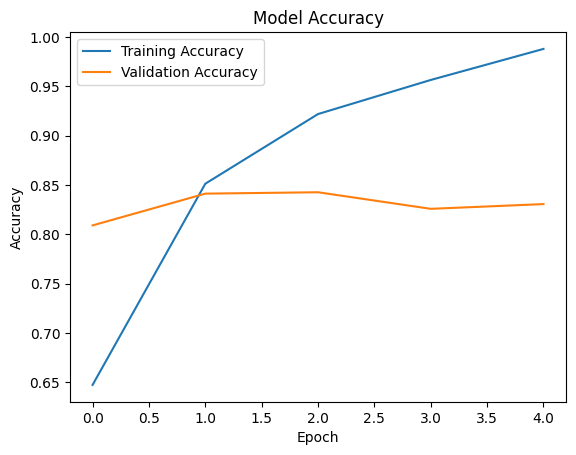

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32))

model.add(SimpleRNN(32))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()